# Chaîne OSF CAPC-AC — Notebook 02 · Cumuls C3S de l'initialisation de septembre 2026 (phase P1)

**Objectif :** passer des fichiers bruts C3S aux **cumuls par période** (décades, mois, saisons) pour chaque modèle, pour la prévision 2026 et pour les 24 années de hindcast. Ce notebook porte ensuite un **premier regard** sur les biais des modèles bruts : c'est ce qui justifie l'étape de calibration (E5).

| Étape | Module |
|---|---|
| Cumuls par période, prévision + hindcast | `eccas_s2s.operations.c3s_totals` (notebook `OP_03`) |
| Comparaison modèle / observation sur la même grille | `eccas_s2s.obs.regrid.match_model_grid` |

Références : Draft Framework §3.1.7 (grille commune avant tout calcul de biais), §3.2 (période de hindcast), §3.7.1 (la correction de biais doit être justifiée par les hindcasts).

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(REPO)
from eccas_s2s.settings import load_cycle
from eccas_s2s.operations.c3s_totals import derived_dir, load_totals
from eccas_s2s.operations.obs_chirps import load_archives
from eccas_s2s.obs.climatology import obs_period_totals
from eccas_s2s.obs.regrid import match_model_grid
from eccas_s2s.core.periods import build_periods
from eccas_s2s.viz.maps import map_panel

cfg = load_cycle("config/cycle_202609.yaml")
SHP = cfg.raw["paths"]["shapefile"]
MODELS = list(cfg.c3s_models)
LABEL = {c: m.label for c, m in cfg.c3s_models.items()}

## 1. Ce qui a été produit

Pour chaque modèle, deux fichiers `c3s_<centre>_precip_{forecast|hindcast}_periods.nc`, de dimensions `(year, number, period, latitude, longitude)` :

- `year` : l'année d'initialisation (2026 pour la prévision, 1993–2016 pour le hindcast) ;
- `period` : la clé de la période relative à l'initialisation (`decade_m0_d1`, `month_m2`, `season_m3`…), avec ses coordonnées `label` et `calendar_key`.

Le nombre de périodes dépend de l'**horizon reçu** de chaque modèle : DWD s'arrête au 28 février (28 périodes), les modèles à 214–215 jours vont jusqu'en mars (33 périodes). Le multi-modèle n'utilisera que les périodes communes.

In [2]:
pd.read_csv(derived_dir(cfg) / "c3s_precip_totals_summary.csv")

,centre,kind,members,years,periods,last_period,missing_year_period
0,ecmwf,forecast,51,1,33,JFM 2027,0
1,ecmwf,hindcast,25,24,33,JFM 2027,0
2,ukmo,forecast,2,1,33,JFM 2027,0
3,ukmo,hindcast,7,24,33,JFM 2027,0
4,meteo_france,forecast,51,1,33,JFM 2027,0
5,meteo_france,hindcast,31,24,33,JFM 2027,0
6,dwd,forecast,50,1,28,DJF 2026-27,0
7,dwd,hindcast,30,24,28,DJF 2026-27,0
8,cmcc,forecast,50,1,28,DJF 2026-27,0
9,cmcc,hindcast,30,24,28,DJF 2026-27,0


## 1 bis. Conformité avec la chaîne v2 (`s2s_processing_v2.py`)

La décumulation et la conversion en mm sont **les mêmes** que dans `run_forecast_v2.py` :

| Opération | Chaîne v2 (`decumulate_precip_to_mm`) | Chaîne OSF (`daily_precip_from_accumulated`) |
|---|---|---|
| conversion | `tp × 1000` (m → mm) | `tp × 1000` (m → mm) |
| 1ᵉʳ jour | valeur du 1ᵉʳ pas (+24 h) | valeur du 1ᵉʳ pas (+24 h) |
| jours suivants | différence entre pas successifs | différence entre pas successifs |
| valeurs négatives | mises à 0 | mises à 0 (et comptées) |

Seules deux choses changent, **après** la décumulation :

1. **Date attribuée :** v2 sélectionne les jours d'une période par `valid_time`. Sa décade « du 1ᵉʳ au 10 » contient donc la pluie tombée du dernier jour du mois précédent au 9, et seulement 9 jours pour la toute première décade, qui n'a pas de jour précédent dans le fichier. OSF prend la pluie tombée du 1ᵉʳ au 10.
2. **Jours manquants :** v2 fait `da.where(masque, 0).sum(...)`, si bien qu'un jour absent compte comme 0 mm sans alerte. OSF rend la période manquante et le signale.

**Vérification :** en appliquant le code v2 **tel quel** aux fenêtres décalées d'un jour, on doit retrouver exactement les cumuls OSF. Exemple ci-dessous avec la prévision ECMWF. Le même contrôle a été fait pour les 7 modèles, en prévision et en hindcast : écart maximal de 0,000 mm dans les 14 cas.

In [3]:
from eccas_s2s.core import processing as v2          # copie à l'identique des fonctions de s2s_processing_v2.py
from eccas_s2s.io.c3s_read import open_c3s_grib
from eccas_s2s.operations.c3s_totals import raw_file

m = cfg.c3s_models["ecmwf"]
per = build_periods(cfg.init_date, m.max_lead_days, cfg.scales)
raw = open_c3s_grib(raw_file(cfg, "ecmwf", "forecast"))
daily_v2 = v2.decumulate_precip_to_mm(raw)
osf = load_totals(cfg, "ecmwf", "forecast").isel(year=0).transpose("number", "period", "latitude", "longitude")

rows = []
for shift, name in ((1, "v2 sur fenêtres décalées +1 j"), (0, "v2 sur ses fenêtres d'origine")):
    pdf = pd.DataFrame([v2._make_period_row(p.scale, p.key, p.dates(2026)[0] + pd.Timedelta(days=shift),
                                            p.dates(2026)[1] + pd.Timedelta(days=shift)) for p in per])
    acc = v2.accumulate_forecast_over_periods(daily_v2, pdf).transpose("number", "period", "latitude", "longitude")
    d = abs(acc.values - osf.values)
    rows.append({"comparaison": name, "écart max (mm)": round(float(d.max()), 3),
                 "écart moyen (mm)": round(float(d.mean()), 3)})
pd.DataFrame(rows)

,comparaison,écart max (mm),écart moyen (mm)
0,v2 sur fenêtres décalées +1 j,0.000,0.000
1,v2 sur ses fenêtres d'origine,285.889,2.152


Dans le tableau de la section 1, **aucune valeur manquante** (`missing_year_period = 0`). Pour DWD et Météo-France, la dernière échéance absente dans certaines années de hindcast tombe au-delà de la dernière période complète, ce que le contrôle qualité avait anticipé.

## 2. La prévision brute SON 2026, modèle par modèle

Moyenne d'ensemble du cumul SON 2026 (grille native 1°) :

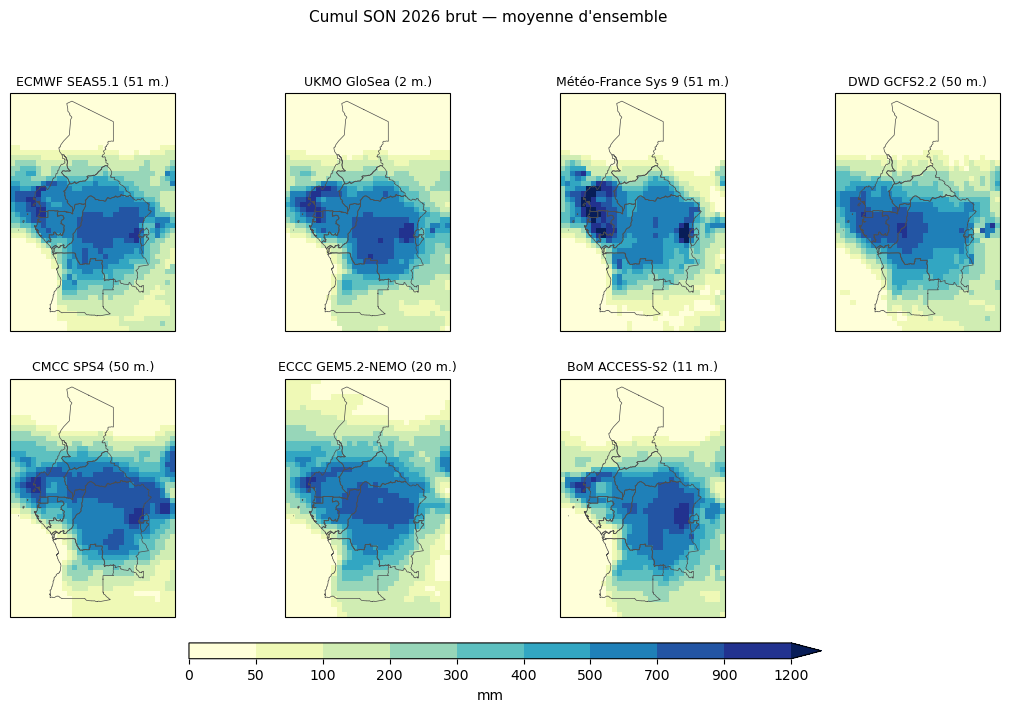

In [4]:
fc = {c: load_totals(cfg, c, "forecast").sel(period="season_m0").isel(year=0) for c in MODELS}
fig = map_panel([fc[c].mean("number") for c in MODELS],
                [f"{LABEL[c]} ({fc[c].sizes['number']} m.)" for c in MODELS],
                shapefile=SHP, cmap="YlGnBu", levels=[0, 50, 100, 200, 300, 400, 500, 700, 900, 1200],
                extend="max", ncols=4, cbar_label="mm", suptitle="Cumul SON 2026 brut — moyenne d'ensemble")

Les modèles s'accordent sur la structure générale (maximum sur la zone équatoriale, dégradé vers le nord), mais les **quantités** diffèrent sensiblement. Une partie de ces écarts est un biais systématique : on le mesure sur les hindcasts.

## 3. Biais de la climatologie des modèles bruts (1993–2016)

Comparaison des cumuls SON moyens sur 1993–2016 : hindcast du modèle (moyenne sur les années et les membres) contre CHIRPS ramené à 1° par moyenne par blocs, sur **les mêmes mailles** et **les mêmes années**.

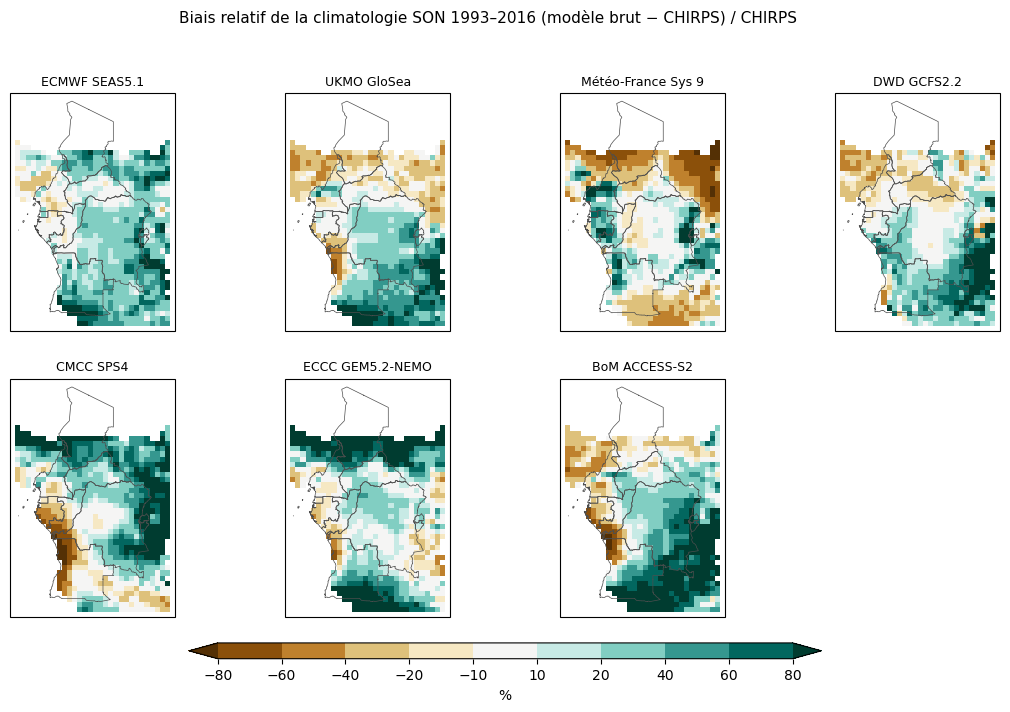

In [5]:
dek1, mon1 = load_archives(cfg, "1p0")
periods = build_periods(cfg.init_date, 181, cfg.scales)
son = [p for p in periods if p.key == "season_m0"]
years = cfg.c3s_hindcast_years
obs = obs_period_totals(dek1, mon1, son, years).sel(period="season_m0")
obs_clim = obs.mean("year")

hc = {c: match_model_grid(load_totals(cfg, c, "hindcast").sel(period="season_m0"), obs_clim) for c in MODELS}
bias_pct = {c: ((hc[c].mean(["year", "number"]) - obs_clim) / obs_clim.where(obs_clim > 50) * 100) for c in MODELS}
fig = map_panel([bias_pct[c] for c in MODELS], [LABEL[c] for c in MODELS], shapefile=SHP, cmap="BrBG",
                levels=[-80, -60, -40, -20, -10, 10, 20, 40, 60, 80], ncols=4, cbar_label="%",
                suptitle="Biais relatif de la climatologie SON 1993–2016 (modèle brut − CHIRPS) / CHIRPS")

In [6]:
w = np.cos(np.deg2rad(obs_clim.latitude)).broadcast_like(obs_clim).where(obs_clim > 50)
tab = pd.DataFrame({
    "biais moyen (%)": {LABEL[c]: float((bias_pct[c] * w).sum() / w.where(bias_pct[c].notnull()).sum()) for c in MODELS},
    "|biais| médian (%)": {LABEL[c]: float(abs(bias_pct[c]).median()) for c in MODELS},
}).round(1)
tab

,biais moyen (%),|biais| médian (%)
ECMWF SEAS5.1,29.1,27.0
UKMO GloSea,14.9,29.0
Météo-France Sys 9,-3.7,26.8
DWD GCFS2.2,17.5,24.2
CMCC SPS4,30.7,34.1
ECCC GEM5.2-NEMO,36.5,23.6
BoM ACCESS-S2,32.9,35.6


## 4. Variabilité interannuelle : le modèle a-t-il la bonne amplitude ?

Un modèle peut avoir la bonne moyenne mais des années trop semblables (variabilité sous-estimée), ou trop contrastées. On compare l'écart-type interannuel observé à celui d'un **membre** du modèle, en moyenne sur les membres. Un rapport de 1 est idéal ; en dessous, le modèle est trop peu variable.

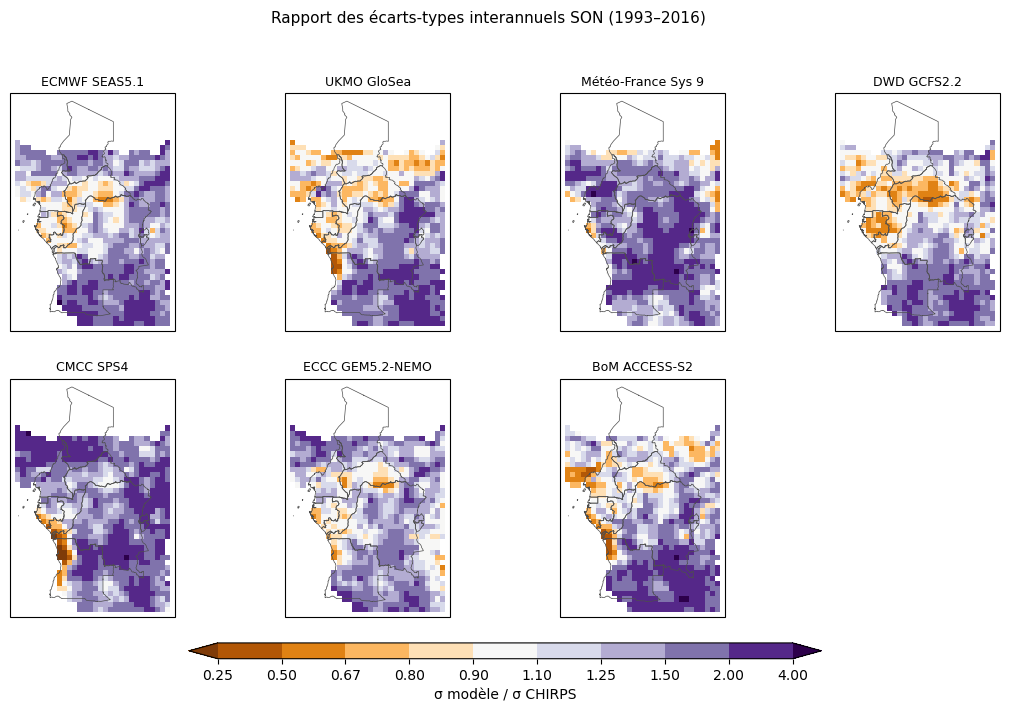

In [7]:
obs_sd = obs.std("year", ddof=1)
ratio = {c: hc[c].std("year", ddof=1).mean("number") / obs_sd.where(obs_clim > 50) for c in MODELS}
fig = map_panel([ratio[c] for c in MODELS], [LABEL[c] for c in MODELS], shapefile=SHP, cmap="PuOr",
                levels=[0.25, 0.5, 0.67, 0.8, 0.9, 1.1, 1.25, 1.5, 2, 4], ncols=4,
                cbar_label="σ modèle / σ CHIRPS", suptitle="Rapport des écarts-types interannuels SON (1993–2016)")

## 5. Pourquoi calibrer

Les sections 3 et 4 montrent des **biais de moyenne** et d'**amplitude** qui varient selon le modèle et la région. Deux conséquences :

1. **Les cumuls bruts ne sont pas directement comparables aux observations.** Les produits bruts actuels contournent le problème en calculant anomalies et terciles par rapport à la climatologie **du modèle lui-même** (hindcast), ce qui corrige le biais de moyenne mais pas le reste.
2. **Les probabilités brutes ne sont pas fiables** si l'ensemble est trop ou pas assez dispersé.

La calibration (E5, phase P3) traitera ces deux points hors échantillon (LOYO) et produira une distribution prévue **dans l'espace des observations**, sur la grille CHIRPS à 0,05°. Les probabilités de catégories y seront calculées avec les seuils communs 1991–2020.

Avant cela, la phase P2 mesurera le **skill brut** de chaque modèle (E4), qui sert de référence : la calibration ne sera retenue que si elle fait mieux.

## 6. Tailles d'ensemble

In [8]:
pd.DataFrame({"membres prévision": {LABEL[c]: int(fc[c].sizes["number"]) for c in MODELS},
              "membres hindcast": {LABEL[c]: int(hc[c].sizes["number"]) for c in MODELS}})

,membres prévision,membres hindcast
ECMWF SEAS5.1,51,25
UKMO GloSea,2,7
Météo-France Sys 9,51,31
DWD GCFS2.2,50,30
CMCC SPS4,50,30
ECCC GEM5.2-NEMO,20,20
BoM ACCESS-S2,11,3


UKMO (2 membres en prévision) et BoM (3 membres en hindcast) sont conservés tels que téléchargés (décision D19). Avec si peu de membres, leurs probabilités brutes sont très grossières : avec 2 membres, une probabilité ne peut valoir que 0, 50 ou 100 %. Les méthodes de calibration fondées sur la **moyenne d'ensemble** (régression, CCA/PCR, NGR) les exploitent mieux que le simple comptage des membres. La pondération par le skill (E6) réglera leur poids dans le multi-modèle.